In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/obesity-prediction/Obesity prediction.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("/kaggle/input/obesity-prediction/Obesity prediction.csv")

In [4]:
def check_df(dataframe):
  print("################### Shape ##################")
  print(dataframe.shape)
  print("################### Types ##################")
  print(dataframe.info())
  print("################### Head ##################")
  print(dataframe.head())
  print("################### Tail ##################")
  print(dataframe.tail())
  print("################### NA ##################")
  print(dataframe.isnull().sum())
  print("################### Quantiles ##################")
  print(dataframe.describe([0, 0.25, 0.50, 0.75, 0.99, 1]).T)

check_df(df)

################### Shape ##################
(2111, 17)
################### Types ##################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 n

Boş değerimiz yok ancak ml problemimiz numerik değerler istedği için encode ve standartlaştırma işlemi yapacağız. Bu yüzden önce kategorik ve numerik değişkenleri ayırmalıyız.

In [5]:
#Değişken türlerini belirliyoruz.
def grab_col_names(dataframe, cat_th=10, car_th=20):
  cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
  num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                 dataframe[col].dtypes != "O"]
  cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                 dataframe[col].dtypes == "O"]

  cat_cols = cat_cols + num_but_cat
  cat_cols = [col for col in cat_cols if col not in cat_but_car]

  num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O" ]
  num_cols = [col for col in num_cols if col not in num_but_cat]

  print(f"Observations: {dataframe.shape[0]}")
  print(f"Variables: {dataframe.shape[1]}")
  print(f'cat_cols: {len(cat_cols)}')
  print(f'num_cols: {len(num_cols)}')
  print(f'cat_but_car: {len(cat_but_car)}')
  print(f'num_but_cat: {len(num_but_cat)}')
  return cat_cols, num_cols,num_but_cat

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2111
Variables: 17
cat_cols: 9
num_cols: 8
cat_but_car: 0
num_but_cat: 0


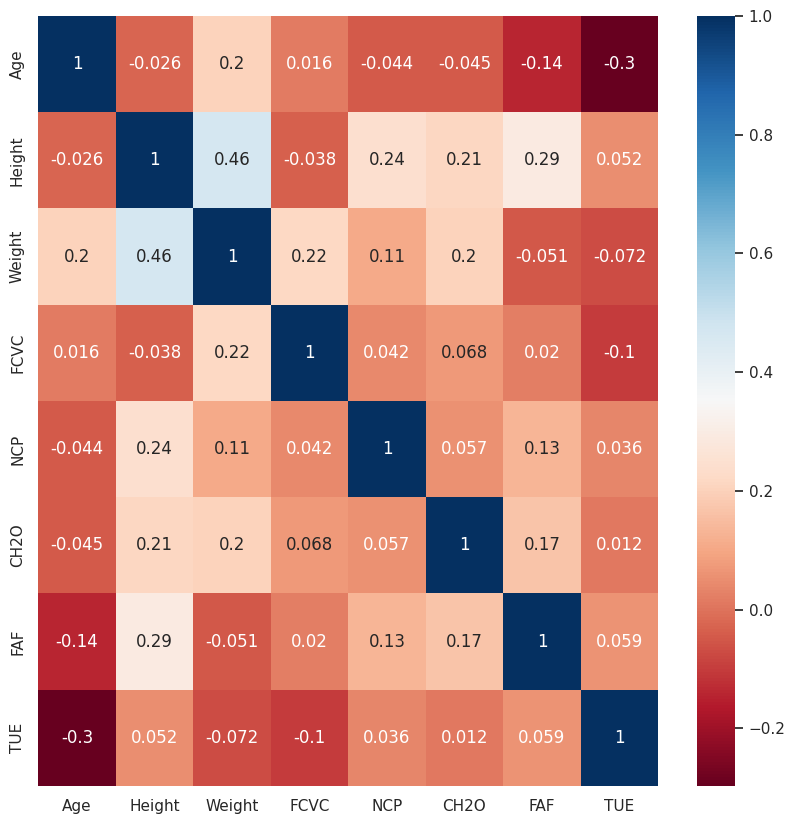

In [6]:
#Korelasyon analizi
corr = df[num_cols].corr()

sns.set(rc={'figure.figsize': (10,10)})
sns.heatmap(corr, cmap="RdBu", annot=True)
plt.show()

**One Hot Encoder**

In [7]:
cat_cols = [col for col in cat_cols if col not in ["Obesity"]]

def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

df = one_hot_encoder(df, cat_cols, drop_first=True)

**Scale**

In [8]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head(5)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Obesity,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,Normal_Weight,False,...,False,False,False,False,False,True,False,False,True,False
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,Normal_Weight,False,...,False,True,True,False,True,False,False,False,True,False
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,Normal_Weight,True,...,False,False,False,True,False,False,False,False,True,False
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,Overweight_Level_I,True,...,False,False,False,True,False,False,False,False,False,True
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,Overweight_Level_II,True,...,False,False,False,False,True,False,False,False,True,False


In [9]:
y = df["Obesity"]
X = df.drop(["Obesity"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {"LR:" : LogisticRegression(),
          "KNN:": KNeighborsClassifier(n_neighbors=5),
          "SVM:": svm.SVC()}

In [10]:
for model_name, model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    print(f"{model_name}")
    print(f"{accuracy*100}")
    print(classification_report(y_test,y_pred))

LR:
86.99763593380615
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      1.00      0.92        56
      Normal_Weight       0.91      0.63      0.74        62
     Obesity_Type_I       0.93      0.90      0.92        78
    Obesity_Type_II       0.90      0.97      0.93        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.74      0.75      0.74        56
Overweight_Level_II       0.74      0.84      0.79        50

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.86       423
       weighted avg       0.87      0.87      0.87       423

KNN:
83.21513002364065
                     precision    recall  f1-score   support

Insufficient_Weight       0.80      0.93      0.86        56
      Normal_Weight       0.78      0.40      0.53        62
     Obesity_Type_I       0.85      0.92      0.88        78
    Obesity_Type_II       0.90      

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [12]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)
svm_model = svm.SVC().fit(X_train_pca, y_train_pca)
y_pred_pca = svm_model.predict(X_test_pca)

print("Classification :")
print(classification_report(y_test_pca,y_pred_pca))

Classification :
                     precision    recall  f1-score   support

Insufficient_Weight       0.44      0.55      0.49        56
      Normal_Weight       0.27      0.34      0.30        62
     Obesity_Type_I       0.45      0.26      0.33        78
    Obesity_Type_II       0.57      0.57      0.57        58
   Obesity_Type_III       0.56      0.79      0.66        63
 Overweight_Level_I       0.25      0.34      0.29        56
Overweight_Level_II       0.43      0.06      0.11        50

           accuracy                           0.42       423
          macro avg       0.42      0.42      0.39       423
       weighted avg       0.43      0.42      0.40       423

